# Brand Index, share price and profit

**Review notebook** for the three experiments that link the Brand Index to Lenovo's finances: `stock_brand_response_v2` (do unexpected Brand Index moves show up in abnormal share-price returns?), `brand_financial_bridge_v1` (do quarterly Brand Index changes show up in reported profit margins?) and `market_implied_earnings_bridge_v1` (the operational per-point earnings coefficient used for planning). It follows the human-review standard in `AGENTS.md` and replaces the July Markdown annexes for these experiments.

The Brand Index is the brand-level index of ADR-0040 (`05_brand_index.ipynb`): 100 = pre-announcement average, 1 point ≈ 1% of Lenovo's brand share of attention. The brand-value valuation that builds on the stock response is in `40_brand_value.ipynb`.

*How to use:* run all cells. Read-only unless `RUN_REBUILD = True`. Narrative numbers are computed from current outputs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in: re-runs the three experiments (about a minute)
    for module in ["srmp.experiments.stock_brand_response_v2", "srmp.experiments.brand_financial_bridge_v1",
                   "srmp.experiments.market_implied_earnings_bridge_v1"]:
        subprocess.run([sys.executable, "-m", module], check=True)

E = "data/curated/experimental/"
S, B, M = E + "stock_brand_response_v2/", E + "brand_financial_bridge_v1/", E + "market_implied_earnings_bridge_v1/"
SOURCES = [
    "config/experiments/stock_brand_response_v2.yaml", "config/experiments/brand_financial_bridge_v1.yaml",
    "config/experiments/market_implied_earnings_bridge_v1.yaml",
    "data/curated/index/brand_index_weekly.parquet", "data/reference/lenovo_quarterly_financials.csv",
    S + "stock_response_manifest.json", S + "stock_response_coefficients.parquet", S + "stock_brand_response_weekly.parquet",
    S + "leave_one_quarter_out_stability.parquet", S + "endpoint_stability.parquet",
    B + "financial_bridge_manifest.json", B + "profit_model_coefficients.parquet", B + "quarterly_financial_bridge.parquet",
    B + "illustrative_monetization_scenarios.parquet",
    M + "market_implied_earnings_bridge_manifest.json", M + "market_implied_earnings_scenarios.parquet",
]
stamp_sources(SOURCES)
sm = json.loads(Path(S + "stock_response_manifest.json").read_text())
bm = json.loads(Path(B + "financial_bridge_manifest.json").read_text())
mm = json.loads(Path(M + "market_implied_earnings_bridge_manifest.json").read_text())

REVIEW_SOURCES={"config/experiments/stock_brand_response_v2.yaml": "fde0a1fc390e4f39167c49f172bf46c4086d8c2f98c61ff77cdea9d5c3a210b6", "config/experiments/brand_financial_bridge_v1.yaml": "8fe0cd7f004284d6f96b22b00b28f5c0906f57ba09c2f70591f514f2cb5caa49", "config/experiments/market_implied_earnings_bridge_v1.yaml": "925ed71adf20d66a3fcf5d635a9e8bf8ca0e2fe4b10d5ed19bc942b08c0cc3ae", "data/curated/index/brand_index_weekly.parquet": "b8599ec9976546d21f2298a5de21c25869eb565e41319e67d69ffae7d2182b7d", "data/reference/lenovo_quarterly_financials.csv": "e418999c1ccf5806c79b09a2b7819069636b3a83e2949a259c84a66b52e4b1ab", "data/curated/experimental/stock_brand_response_v2/stock_response_manifest.json": "371b8d1dad36b373744fb797bbcf22997f4d858358267e65a17041e733cf50ad", "data/curated/experimental/stock_brand_response_v2/stock_response_coefficients.parquet": "1ac24ff0f82f04295d5834864926be1de8580c3b48df0a1740a95df9006b529d", "data/curated/experimental/stock_brand_response_v2/stock_brand_response_w

## 1. Question and purpose

**Questions.** (a) When the Brand Index moves more than expected in a week, does Lenovo's share price move more than the market would explain? (b) When the Brand Index rises over a quarter, does Lenovo's reported profit margin rise? (c) What per-point earnings coefficient does the project use for planning, and on what basis?

**Why it matters.** A brand lift is only worth money if it reaches cash flows or the market's valuation of them. These experiments test that link directly, without assuming it.

**Objective supported.** Monetisation of the sponsorship's brand uplift; the stock response also feeds the brand-share-of-price-formation valuation in `40_brand_value.ipynb`.

## 2. Evidence and inputs

| Input | Source | Frequency | Label |
|---|---|---|---|
| Lenovo (0992.HK), Hang Seng, Nasdaq-100, USD/HKD closes | Yahoo Finance chart API | daily | **observed** |
| Lenovo Brand Index | `data/curated/index/brand_index_weekly.parquet` (ADR-0040) | weekly | **constructed** |
| PC-category demand | Google Trends for Dell, Asus, Acer, HP laptop, Microsoft Surface, MacBook (joint panel) | weekly | **observed** → **constructed** (log changes) |
| Lenovo product, promotion and mixed events; results-release dates | Lenovo press releases and investor calendar (`data/reference/`) | event | **observed** |
| Quarterly revenue and adjusted net income | Lenovo official financial highlights (`lenovo_quarterly_financials.csv`) | quarterly | **observed** |
| FY25/26 adjusted net income, shares, market cap at 31 Mar 2026 | Lenovo FY2025/26 annual report | annual | **observed** |
| Zero floor on the planning coefficient | Project rule | – | **assumed** |

## 3. Method and formulas

**Abnormal returns (no look-ahead).** For each trading day $d$, Lenovo's log return is predicted from a market model fitted on the 120 trading days *before* $d$:

$$\hat r_d = \hat a + \hat b_1\, \text{HSI}_d + \hat b_2\, \text{NDX}^{HKD}_{d-1}, \qquad AR_d = r_d - \hat r_d .$$

*In words:* the part of Lenovo's daily return that the Hong Kong market and the previous Nasdaq session do not explain. Weekly abnormal returns sum the days.

**Brand Index innovation.** The weekly Brand Index change $\Delta BI_t$ is predicted from up to 104 *prior* weeks (lagged change, category demand, events, seasonality); the innovation is $\varepsilon_t = \Delta BI_t - \widehat{\Delta BI}_t$. *In words:* the part of this week's brand move that could not have been foreseen.

**Stock response.** For horizons $h \in \{0, 1, 4, 13\}$ weeks,

$$CAR_{t,h} = \alpha_h + \beta_h\, \varepsilon_t + \text{controls}_t + u_{t,h},$$

with lagged abnormal return, lagged volatility, category demand, product/promotion/mixed events and results-release weeks as controls; Newey–West errors; the four horizons are one Holm-corrected family. $\beta_h$ is in percentage points of cumulative abnormal return per unexpected Brand Index point.

**Quarterly profit bridge.** For quarter $q$, with adjusted margin $m_q = 100 \cdot \text{adjusted net income}_q / \text{revenue}_q$,

$$\Delta m_q = \alpha + \beta\, \Delta BI_q + \gamma\, \Delta \text{category}_q + \theta_1 \text{HSI}_q + \theta_2 \text{NDX}^{HKD}_q + e_q ,$$

in first differences only, HC3 errors. *In words:* do quarters with larger Brand Index gains have larger margin gains, after market and category movements?

**Market-implied earnings coefficient (planning).** With a constant earnings multiple, the immediate stock response $\beta_0$ (percent per point) applies equally to market-implied annual adjusted earnings $E$:

$$\text{US\$ per point per year} = \max(0, \beta_0) \cdot E, \qquad \text{planning range} = [0,\ \max(0, \beta_0^{upper})\cdot E].$$

*In words:* one Brand Index point is worth the share of annual earnings the market capitalises when the index moves; the zero floor is a planning rule (a brand gain is not valued negatively), not a statistical result.

## 4. Calculation path

| Step | Code | Configuration | Output read here |
|---|---|---|---|
| Rolling factor model, abnormal returns | `srmp/experiments/stock_brand_response_v2.py` (`_rolling_factor_returns`) | `config/experiments/stock_brand_response_v2.yaml` | `stock_brand_response_v2/` |
| Brand Index innovations | same (`_add_brand_index_innovations`) | same | `stock_brand_response_weekly.parquet` |
| Horizon regressions, Holm, placebos, stability | same | same | `stock_response_coefficients`, `leave_one_quarter_out_stability`, `endpoint_stability` |
| Quarterly panel and profit models | `srmp/experiments/brand_financial_bridge_v1.py` | `config/experiments/brand_financial_bridge_v1.yaml` | `brand_financial_bridge_v1/` |
| Per-point earnings mapping | `srmp/experiments/market_implied_earnings_bridge_v1.py` | `config/experiments/market_implied_earnings_bridge_v1.yaml` | `market_implied_earnings_bridge_v1/` |

## 5. Results

### 5.1 Unexpected Brand Index moves

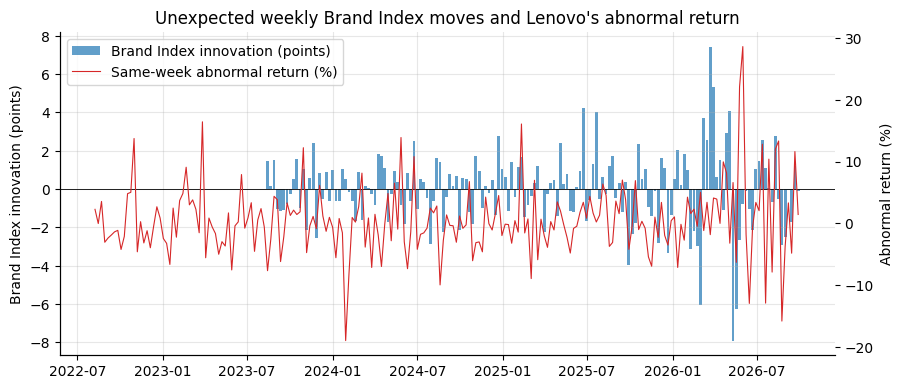

**Figure 1.** 164 weeks with an innovation (52 weeks of history needed first). Innovation standard deviation 1.93 points; abnormal-return standard deviation 5.66%.

In [2]:
wk = pd.read_parquet(S + "stock_brand_response_weekly.parquet"); wk["week"] = pd.to_datetime(wk["week"])
fig, ax = plt.subplots()
ax.bar(wk["week"], wk["brand_index_innovation"], width=6, color="tab:blue", alpha=0.7, label="Brand Index innovation (points)")
ax2 = ax.twinx()
ax2.plot(wk["week"], 100 * wk["forward_abnormal_return_h0"], color="tab:red", lw=0.8, label="Same-week abnormal return (%)")
ax2.set_ylabel("Abnormal return (%)"); ax2.grid(False)
ax.set_ylabel("Brand Index innovation (points)"); ax.axhline(0, color="k", lw=0.6)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax.legend(h1 + h2, l1 + l2, loc="upper left")
ax.set_title("Unexpected weekly Brand Index moves and Lenovo's abnormal return"); plt.show()
md(f"**Figure 1.** {sm['brand_index_shock']['innovation_observations']} weeks with an innovation (52 weeks of history needed first). "
   f"Innovation standard deviation {wk['brand_index_innovation'].std():.2f} points; abnormal-return standard deviation {100*wk['forward_abnormal_return_h0'].std():.2f}%.")

### 5.2 Stock response by horizon

In [3]:
hr = pd.DataFrame(sm["horizon_results"]).rename(columns={
    "horizon_weeks": "Horizon (weeks)", "abnormal_return_percentage_points_per_BI_innovation_point": "Response (pp per point)",
    "robust_se_percentage_points": "Robust s.e.", "lower_95_percentage_points": "95% low", "upper_95_percentage_points": "95% high",
    "p_value_normal_approx": "p", "p_value_holm": "Holm p"})
display(hr.style.format(precision=3).hide(axis="index"))
rp = sm["reverse_timing_placebo"]
md(f"**Table 1.** Any Holm-adjusted p ≤ 0.10: **{sm['multiple_testing']['any_adjusted_p_at_or_below_0_10']}**. "
   f"Reverse-timing placebo (innovation {rp['lead_weeks']} weeks *after* the return): {rp['estimate_percentage_points']:+.3f} pp, p = {rp['p_value_normal_approx']:.2f}.")

Horizon (weeks),Response (pp per point),Robust s.e.,95% low,95% high,p,Holm p
0,0.244,0.262,-0.269,0.756,0.352,1.000
1,-0.064,0.382,-0.812,0.684,0.866,1.000
4,-0.247,0.912,-2.034,1.540,0.787,1.000
13,0.192,1.182,-2.125,2.509,0.871,1.000


**Table 1.** Any Holm-adjusted p ≤ 0.10: **False**. Reverse-timing placebo (innovation 4 weeks *after* the return): -0.209 pp, p = 0.35.

In [4]:
lq = pd.read_parquet(S + "leave_one_quarter_out_stability.parquet")
ep = pd.read_parquet(S + "endpoint_stability.parquet")
lq_sum = lq.groupby("horizon_weeks")["estimate"].agg(**{"Lowest estimate": "min", "Highest estimate": "max",
                                                        "Share positive": lambda s: (s > 0).mean()})
display((100 * lq_sum.iloc[:, :2]).join(lq_sum.iloc[:, 2]).rename_axis("Horizon (weeks)").style.format(
    {"Lowest estimate": "{:+.3f}", "Highest estimate": "{:+.3f}", "Share positive": "{:.0%}"}))
display(ep.assign(estimate=100 * ep["estimate"]).rename(columns={"sample_endpoint": "Sample ends", "horizon_weeks": "Horizon (weeks)",
        "estimate": "Response (pp per point)", "robust_se": "Robust s.e. (share)", "p_value_normal_approx": "p", "observations": "Weeks"})
        .style.format({"Response (pp per point)": "{:+.3f}", "Robust s.e. (share)": "{:.4f}", "p": "{:.2f}"}).hide(axis="index"))
flips = [int(h) for h, row in lq_sum.iterrows() if 0 < row["Share positive"] < 1] + sorted({int(h) for h in ep["horizon_weeks"]
         if (ep.loc[ep["horizon_weeks"].eq(h), "estimate"] > 0).nunique() > 1})
md("**Tables 2–3.** Leaving out one calendar quarter at a time (pp per point) and stopping the sample at earlier end dates. "
   + (f"The sign changes across these checks at horizon(s) {sorted(set(flips))} weeks: the response is not pinned down." if flips
      else "The sign is stable across these checks."))

,Lowest estimate,Highest estimate,Share positive
Horizon (weeks),,,
0,-0.014,+0.430,92%
1,-0.318,+0.258,8%
4,-0.660,+0.083,8%
13,-0.850,+1.695,77%


Sample ends,Horizon (weeks),Response (pp per point),Robust s.e. (share),p,Weeks
2024-12-31 00:00:00,0,+0.083,0.0047,0.86,73
2024-12-31 00:00:00,1,-0.641,0.0050,0.20,72
2024-12-31 00:00:00,4,-0.728,0.0068,0.29,69
2024-12-31 00:00:00,13,-1.067,0.0071,0.13,60
2025-12-31 00:00:00,0,+0.331,0.0027,0.22,125
2025-12-31 00:00:00,1,+0.059,0.0034,0.86,124
2025-12-31 00:00:00,4,+0.018,0.0050,0.97,121
2025-12-31 00:00:00,13,+1.020,0.0082,0.22,112
2026-09-28 00:00:00,0,+0.244,0.0026,0.35,164
2026-09-28 00:00:00,1,-0.064,0.0038,0.87,163


**Tables 2–3.** Leaving out one calendar quarter at a time (pp per point) and stopping the sample at earlier end dates. The sign changes across these checks at horizon(s) [0, 1, 4, 13] weeks: the response is not pinned down.

### 5.3 Quarterly profit bridge

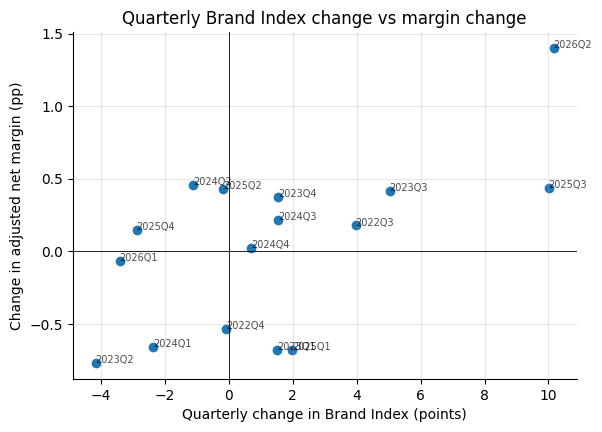

Model,pp margin per point,HC3 s.e.,95% low,95% high,p
margin_uncontrolled,0.085,0.039,0.010,0.161,0.027
margin_category,0.007,0.053,-0.096,0.110,0.894
margin_macro,0.009,0.061,-0.110,0.128,0.882
margin_seasonality,0.010,0.079,-0.145,0.165,0.898
margin_all_controls,0.018,0.089,-0.157,0.192,0.840


**Figure 2 and Table 4.** 16 quarterly first differences. Primary model: **margin_macro**. Adjusted-profit growth sensitivity: +2.9% per point (95% -4.1% to +10.3%, p = 0.43). Decision: No coefficient is approved for sponsorship monetization because the quarterly sample has only 16 first differences and the controlled estimates are imprecise (every controlled 95% interval includes zero).

In [5]:
qp = pd.read_parquet(B + "quarterly_financial_bridge.parquet")
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(qp["delta_brand_index"], qp["delta_adjusted_net_margin_pp"], color="tab:blue")
for _, r in qp.dropna(subset=["delta_brand_index"]).iterrows():
    ax.annotate(r["calendar_quarter"], (r["delta_brand_index"], r["delta_adjusted_net_margin_pp"]), fontsize=7, alpha=0.7)
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("Quarterly change in Brand Index (points)"); ax.set_ylabel("Change in adjusted net margin (pp)")
ax.set_title("Quarterly Brand Index change vs margin change"); plt.show()
models = pd.DataFrame(bm["margin_model_sensitivity"]["models"]).rename(columns={
    "model": "Model", "estimate": "pp margin per point", "robust_se": "HC3 s.e.", "lower_95": "95% low", "upper_95": "95% high", "p_value_normal_approx": "p"})
display(models.style.format(precision=3).hide(axis="index"))
g = bm["controlled_profit_growth_sensitivity"]
md(f"**Figure 2 and Table 4.** {int(qp['delta_brand_index'].notna().sum())} quarterly first differences. Primary model: **{bm['primary_profit_mapping']['model']}**. "
   f"Adjusted-profit growth sensitivity: {g['approximate_percent']:+.1f}% per point (95% {g['lower_95_percent']:+.1f}% to {g['upper_95_percent']:+.1f}%, p = {g['p_value_normal_approx']:.2f}). "
   f"Decision: {bm['decision']}")

### 5.4 Market-implied earnings coefficient (planning)

In [6]:
sel, op, xc = mm["selected_stock_response"], mm["operational_unit_mapping"], mm["market_value_cross_check"]
display(pd.DataFrame([
    ("Immediate stock response (h = 0), % per point", f"{sel['empirical_return_percent_per_BI_point']:+.3f} (95% {sel['empirical_lower_95_percent']:+.3f} to {sel['empirical_upper_95_percent']:+.3f})"),
    ("Planning response after zero floor, % per point", f"{sel['planning_return_percent_per_BI_point']:.3f} (range {sel['planning_lower_percent']:.3f} to {sel['planning_upper_percent']:.3f})"),
    (f"Annual adjusted earnings {op['fiscal_year']} (US$m)", f"{op['annual_adjusted_earnings_base_usd_m']:,.0f}"),
    ("Earnings-equivalent per point per year (US$m)", f"{op['annual_adjusted_earnings_usd_m_per_BI_point']:.2f} (planning {op['planning_lower_usd_m_per_BI_point']:.1f} to {op['planning_upper_usd_m_per_BI_point']:.1f})"),
    (f"Cross-check: market cap {xc['reference_date']} (US$m) × response", f"{xc['official_market_cap_usd_m']:,.0f} → US${xc['equity_value_usd_m_per_BI_point']:.1f}m equity value per point"),
    ("÷ adjusted earnings multiple", f"{xc['adjusted_earnings_multiple']:.2f}× → US${xc['equity_value_divided_by_multiple_usd_m']:.2f}m per year (reconciles)"),
], columns=["Step", "Value"]).style.hide(axis="index"))
sc = pd.read_parquet(M + "market_implied_earnings_scenarios.parquet")
display(sc[["case", "role", "delta_brand_index_points", "annual_adjusted_earnings_percent_equivalent", "annual_adjusted_earnings_usd_m_central",
            "annual_adjusted_earnings_usd_m_planning_lower", "annual_adjusted_earnings_usd_m_planning_upper", "attribution_accepted"]].rename(columns={
    "case": "Case", "role": "Status", "delta_brand_index_points": "Brand Index points", "annual_adjusted_earnings_percent_equivalent": "% of annual earnings",
    "annual_adjusted_earnings_usd_m_central": "US$m per year (central)", "annual_adjusted_earnings_usd_m_planning_lower": "Planning low",
    "annual_adjusted_earnings_usd_m_planning_upper": "Planning high", "attribution_accepted": "Attribution accepted"})
    .style.format({"Brand Index points": "{:+.2f}", "% of annual earnings": "{:.2f}", "US$m per year (central)": "{:,.1f}",
                   "Planning low": "{:,.1f}", "Planning high": "{:,.1f}"}).hide(axis="index"))
md("**Tables 5–6.** The per-point coefficient applied to the sponsorship cases. Status shows which cases rest on an accepted attribution.")

Step,Value
"Immediate stock response (h = 0), % per point",+0.244 (95% -0.269 to +0.756)
"Planning response after zero floor, % per point",0.244 (range 0.000 to 0.756)
Annual adjusted earnings FY25/26 (US$m),"2,049"
Earnings-equivalent per point per year (US$m),4.99 (planning 0.0 to 15.5)
Cross-check: market cap 2026-03-31 (US$m) × response,"14,500 → US$35.3m equity value per point"
÷ adjusted earnings multiple,7.08× → US$4.99m per year (reconciles)


Case,Status,Brand Index points,% of annual earnings,US$m per year (central),Planning low,Planning high,Attribution accepted
one_brand_index_point,unit_mapping,+1.00,0.24,5.0,0.0,15.5,True
total_sponsorship_effect,attribution_not_accepted,+7.48,1.82,37.3,0.0,115.9,False
world_cup_total_path_interim,interim_not_accepted,+7.14,1.74,35.6,0.0,110.7,False
world_cup_incremental_interim,interim_not_accepted,+3.60,0.88,18.0,0.0,55.8,False


**Tables 5–6.** The per-point coefficient applied to the sponsorship cases. Status shows which cases rest on an accepted attribution.

## 6. Interpretation

In [7]:
h0 = sm["horizon_results"][0]
md(f"""- **Share price.** An unexpected one-point rise in the Brand Index is followed by a same-week abnormal return of {h0['abnormal_return_percentage_points_per_BI_innovation_point']:+.2f} pp
  (95% {h0['lower_95_percentage_points']:+.2f} to {h0['upper_95_percentage_points']:+.2f}); {'no' if not sm['multiple_testing']['any_adjusted_p_at_or_below_0_10'] else 'at least one'} horizon is significant after the Holm correction.
  {'The share price does not detectably respond to brand moves at this sample size.' if not sm['multiple_testing']['any_adjusted_p_at_or_below_0_10'] else 'At least one horizon shows a detectable response.'}
- **Profit.** Quarters with larger Brand Index gains have {'larger' if bm['primary_profit_mapping']['estimate'] > 0 else 'smaller'} margin gains in the primary model
  ({bm['primary_profit_mapping']['estimate']:+.3f} pp per point, 95% {bm['primary_profit_mapping']['lower_95']:+.3f} to {bm['primary_profit_mapping']['upper_95']:+.3f}); the
  {(lambda u: f"uncontrolled association is {u['estimate']:+.3f} pp (p = {u['p_value_normal_approx']:.2f}) and "
   + ("does not survive" if all(m['lower_95'] < 0 for m in bm['margin_model_sensitivity']['models'] if m['model'] != 'margin_uncontrolled') else "survives")
   + " market and category controls.")(next(m for m in bm['margin_model_sensitivity']['models'] if m['model'] == 'margin_uncontrolled'))}
- **Planning coefficient.** The project's operational mapping is US${op['annual_adjusted_earnings_usd_m_per_BI_point']:.1f}m of market-implied annual earnings per Brand Index point
  (planning range US${op['planning_lower_usd_m_per_BI_point']:.0f}–{op['planning_upper_usd_m_per_BI_point']:.0f}m). Its central value is the empirical point estimate; its lower end is the zero floor, not data.
- **Decision relevance.** None of these links is statistically identified; they are planning translations of a borderline brand lift, not evidence that the brand lift raised profit or value.""")

- **Share price.** An unexpected one-point rise in the Brand Index is followed by a same-week abnormal return of +0.24 pp
  (95% -0.27 to +0.76); no horizon is significant after the Holm correction.
  The share price does not detectably respond to brand moves at this sample size.
- **Profit.** Quarters with larger Brand Index gains have larger margin gains in the primary model
  (+0.009 pp per point, 95% -0.110 to +0.128); the
  uncontrolled association is +0.085 pp (p = 0.03) and does not survive market and category controls.
- **Planning coefficient.** The project's operational mapping is US$5.0m of market-implied annual earnings per Brand Index point
  (planning range US$0–15m). Its central value is the empirical point estimate; its lower end is the zero floor, not data.
- **Decision relevance.** None of these links is statistically identified; they are planning translations of a borderline brand lift, not evidence that the brand lift raised profit or value.

## 7. Limitations and non-claims

- **Association, not causation.** Share-price and margin regressions on one company cannot rule out reverse causality (good results raising brand interest) or omitted variables.
- **Low power.** A few hundred weekly innovations and fewer than twenty quarterly differences (counts in the Figure 1 and Figure 2 captions); intervals are wide and sign changes across stability checks are common.
- **Abnormal returns are not profit.** The stock response is the market's revaluation, which also reflects expectations, not cash flow already earned.
- **Zero floor and constant multiple are assumptions.** The planning range is a decision range, not a confidence interval.
- **Units changed (ADR-0040).** Coefficients are per point of the brand-level Brand Index (≈ 1% of brand share of attention); July figures in the superseded Markdown annexes used the old 100/15 search-salience scale and are not comparable.

## Next steps

1. Re-estimate after the post-18 October data refresh.
2. Treat the planning coefficient as a scenario input only until a brand-to-cash-flow link is identified (for example from survey purchase-driver data).